<a href="https://colab.research.google.com/github/haniyathul/Praktikum-Analisis-Deret-Waktu/blob/main/Tugas_Praktikum_STA2542_Minggu_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PRAKTIKUM 1 ANALISIS DERET WAKTU
# HANIYATHUL HUSNA (M0501251011)

catatan: data simulasi

seed(1011)

parameter = +11

# Kecenderungan dalam Deret Waktu

Misalkan suatu deret waktu memiliki fungsi nilaitengah konstan. Model untuk deret waktu tersebut dapat dituliskan sebagai berikut:

$Y_t=\mu_t+X_t$

dengan $E(X_t)=0$ untuk semua $t$.

## **Kecenderungan Linear**

Deret dikatakan memiliki kecenderungan linear dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t$

Berikut simulasi deret yang memiliki kecenderungan linear dalam waktu.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

In [2]:
# membangkitkan data waktu dalam bentuk array (misalnya, 100 bulan)
np.random.seed(1011)
n=100
t = np.arange(n)

# Membuat deret dengan kecenderungan linear
beta1 = 0.5+11
beta0 = 10*11
deret = beta0 + beta1*t

# Menambahkan ingar acak
noise = np.random.normal(scale=2, size=n)  # Noise dengan standar deviasi 2
time_series = deret + noise  # Menggabungkan tren dengan noise

# Membuat DataFrame untuk menyimpan data
df = pd.DataFrame({"Time": pd.date_range(start="2017-01-01", periods=100, freq="M"),
                   "Value": time_series})
df

,Time,Value
0,2017-01-31,107.691582
1,2017-02-28,124.645269
2,2017-03-31,131.284487
3,2017-04-30,145.059628
4,2017-05-31,155.801181
...,...,...
95,2024-12-31,1204.560875
96,2025-01-31,1215.489830
97,2025-02-28,1222.592021
98,2025-03-31,1237.464826


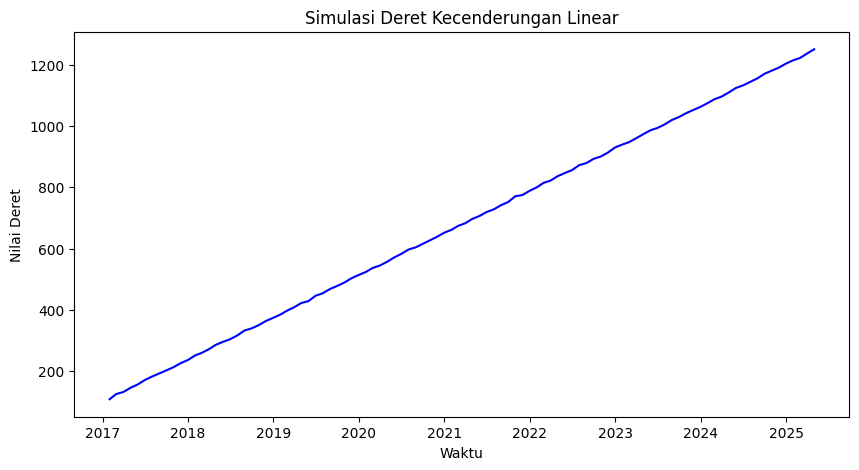

In [3]:
# Plot deret waktu dengan tren linear
plt.figure(figsize=(10, 5))
plt.plot(df["Time"], df["Value"], color="b")
plt.xlabel("Waktu")
plt.ylabel("Nilai Deret")
plt.title("Simulasi Deret Kecenderungan Linear")
plt.show()

Cek apakah ada korelasi antar pengamatan?

Dari grafik:

Nilai deret meningkat secara konsisten dari waktu ke waktu.
Pengamatan yang berdekatan memiliki nilai yang relatif berdekatan, sehingga menunjukkan ketergantungan antar pengamatan.
Polanya hampir membentuk garis lurus, sehingga korelasi antar waktu kemungkinan sangat kuat dan positif.
Namun, grafik saja belum cukup untuk memastikan autokorelasi. Korelasi tersebut bisa terutama disebabkan oleh tren (nonstasioneritas)..

In [4]:
# Konversi kolom Time menjadi angka (misalnya jumlah bulan sejak periode pertama)
df["Time_Numeric"] = (df["Time"].dt.to_period("M") - df["Time"].dt.to_period("M").min()).apply(lambda x: x.n)

# Hitung korelasi antara Time_Numeric dan Value
correlation = df["Time_Numeric"].corr(df["Value"])

print(f"Nilai korelasi antara Time dan Value: {correlation:.4f}")

Nilai korelasi antara Time dan Value: 1.0000


Berdasarkan hasil perhitungan, diperoleh nilai korelasi antara waktu dan nilai deret sebesar 1,0000. Nilai tersebut menunjukkan adanya hubungan linear positif yang sempurna antara waktu dan nilai deret. Artinya, peningkatan waktu selalu diikuti oleh peningkatan nilai deret secara konsisten. Hasil ini mengindikasikan adanya kecenderungan (trend) linear yang sangat kuat pada deret waktu.

In [5]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = df["Time_Numeric"]
Y = df["Value"]

#memanggil package statsmodels
import statsmodels.api as sm

# Tambahkan konstanta (intercept) ke model regresi
X = sm.add_constant(X)

# Buat dan jalankan model regresi
model = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.325e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          8.02e-224
Time:                        14:12:54   Log-Likelihood:                -200.80
No. Observations:                 100   AIC:                             405.6
Df Residuals:                      98   BIC:                             410.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          110.1123      0.361    304.673   

**Bagaimana hasil pengepasan model regresi dibandingkan dengan nilai parameter asli?**

Model yang diperoleh adalah:
Model yang dipaskan adalah:

$$ \hat{Value}=110.1123+11.5016(Time\_Numeric) $$

Jadi hasil estimasi parameternya:
Artinya, setiap pertambahan 1 satuan waktu, nilai Value meningkat sekitar 11,50 satuan.

Karena dari simulasi grafik terlihat deret memang dibuat dengan kecenderungan linear yang sangat kuat, hasil estimasi tersebut menunjukkan bahwa model berhasil menangkap parameter dan pola linear asli dengan sangat baik.

**Apakah model regresi yang dipaskan sudah bagus?**

$R^2$ sebesar 1,000 yang menunjukkan bahwa hampir seluruh variasi nilai deret dapat dijelaskan oleh waktu.

Koefisien waktu juga signifikan secara statistik dengan p-value < 0,001. Selain itu, nilai Durbin-Watson sebesar 2,350 menunjukkan tidak adanya indikasi autokorelasi residual yang kuat, sedangkan uji Jarque-Bera menghasilkan p-value sebesar 0,178 sehingga residual tidak menunjukkan penyimpangan yang signifikan dari normalitas. Dengan demikian, model regresi yang dipaskan dapat dikatakan sangat baik dalam menggambarkan pola linear pada data simulasi.

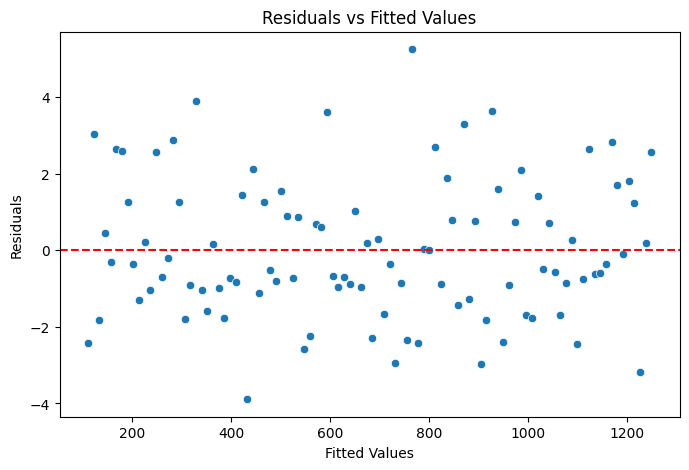

In [6]:
# Analisis Sisaan Model
import seaborn as sns

# Plot Residuals vs. Fitted Values
plt.figure(figsize=(8,5))
sns.scatterplot(x=model.fittedvalues, y=model.resid)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()


**Apa interpretasi dari plot tersebut?**

Berdasarkan plot Residuals vs Fitted Values, residual terlihat menyebar secara acak di sekitar garis nol dan tidak membentuk pola sistematis tertentu. Penyebaran residual juga relatif merata pada berbagai nilai fitted value sehingga tidak terdapat indikasi kuat adanya pelanggaran asumsi linearitas maupun heteroskedastisitas. Dengan demikian, model regresi linear yang digunakan telah mampu menggambarkan pola hubungan antara waktu dan nilai deret dengan cukup baik.

In [7]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Uji Breusch-Pagan
bp_test = het_breuschpagan(model.resid, model.model.exog)

print(f"P-value Breusch-Pagan Test: {bp_test[1]:.4f}")


P-value Breusch-Pagan Test: 0.9765


**Apa kesimpulan dari nilai uji Breusch Pagan tersebut?**

Hasil uji Breusch-Pagan:

p-value = 0,9765

Dengan taraf signifikansi α = 5% (0,05):

H₀: tidak terdapat heteroskedastisitas , varians residual konstan (homoskedastisitas)
H₁: terdapat heteroskedastisitas , varians residual tidak konstan

Karena:

$$ 0,9765 > 0,05 $$

maka H₀ tidak ditolak.

Kesimpulan

Tidak terdapat bukti adanya heteroskedastisitas pada model regresi. Dengan kata lain, residual dapat dianggap memiliki varians yang konstan (homoskedastisitas).

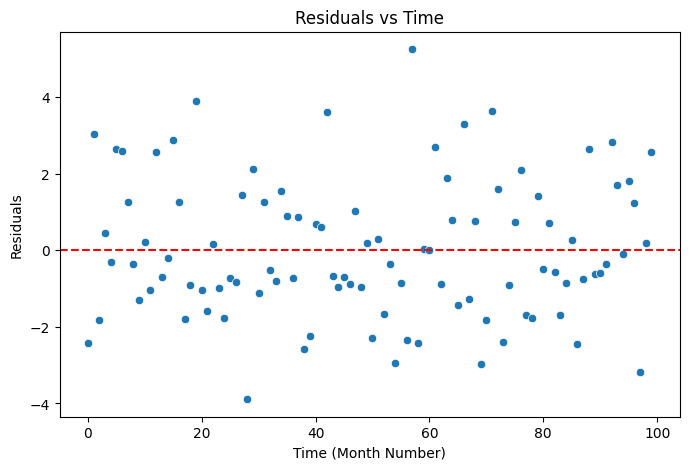

In [8]:
# Plot residual vs time
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Time_Numeric"], y=model.resid)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Time (Month Number)")
plt.ylabel("Residuals")
plt.title("Residuals vs Time")
plt.show()


<Figure size 800x500 with 0 Axes>

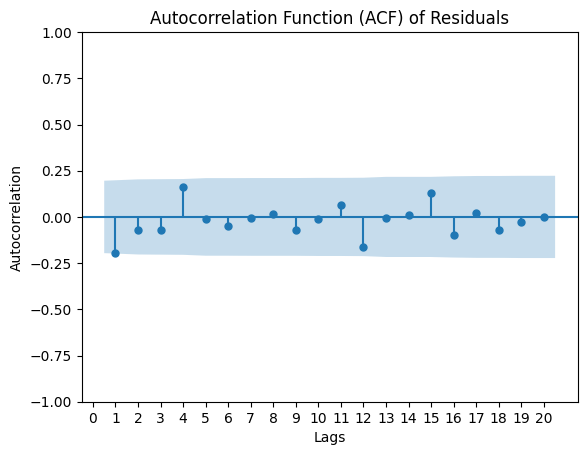

In [9]:
from statsmodels.graphics.tsaplots import plot_acf

# Plot Autocorrelation Function (ACF)
plt.figure(figsize=(8, 5))
plot_acf(model.resid, lags=20, zero=False)
plt.xticks(ticks=range(0, 21, 1))
plt.title("Autocorrelation Function (ACF) of Residuals")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.show()


**Apa yang dapat Anda simpulkan dari plot di atas?**
1. Plot Residuals vs Time

Residual terlihat menyebar di sekitar garis nol (0) dan tidak menunjukkan pola tertentu, seperti tren naik/turun atau pola berulang yang jelas. Sebagian besar residual berada di sekitar nol, meskipun terdapat beberapa residual yang cukup besar.
Kesimpulan: residual cenderung acak dan tidak menunjukkan pola sistematis terhadap waktu, sehingga asumsi independensi residual secara visual cukup terpenuhi.

2. Plot ACF Residual

Pada plot ACF, hampir seluruh nilai autokorelasi pada lag 1-20 berada di dalam batas confidence interval (area biru). Tidak ada spike yang secara jelas melewati batas tersebut.
Kesimpulan: tidak terdapat autokorelasi yang signifikan pada residual. Dengan demikian, residual dapat dianggap tidak memiliki ketergantungan serial yang berarti.

In [10]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Uji Ljung-Box untuk autokorelasi residual
ljung_box_test = acorr_ljungbox(model.resid, lags=range(1,20), return_df=True)

print("Ljung-Box Test p-value:")
print(ljung_box_test)


Ljung-Box Test p-value:
      lb_stat  lb_pvalue
1    3.884175   0.048743
2    4.397659   0.110933
3    4.890182   0.180017
4    7.698307   0.103276
5    7.713937   0.172722
6    7.961780   0.240917
7    7.964393   0.335744
8    7.990091   0.434439
9    8.554266   0.479393
10   8.566846   0.573644
11   9.007840   0.621169
12  12.099925   0.437688
13  12.102050   0.519294
14  12.121457   0.596549
15  14.173535   0.512411
16  15.308335   0.502182
17  15.352431   0.570113
18  15.974404   0.594334
19  16.063699   0.653024


Apa kesimpulan dari hasil uji Ljung-Box tersebut?

Khusus pada lag 1, p-value = 0.048743 < 0.05, sehingga terdapat indikasi autokorelasi pada lag 1.

Tetapi mulai lag 2 sampai lag 19, seluruh p-value > 0.05, sehingga tidak terdapat bukti autokorelasi yang signifikan pada lag-lag tersebut.

Dengan demikian, secara umum residual tidak menunjukkan autokorelasi yang kuat dan sistematis, meskipun terdapat indikasi autokorelasi pada lag pertama.

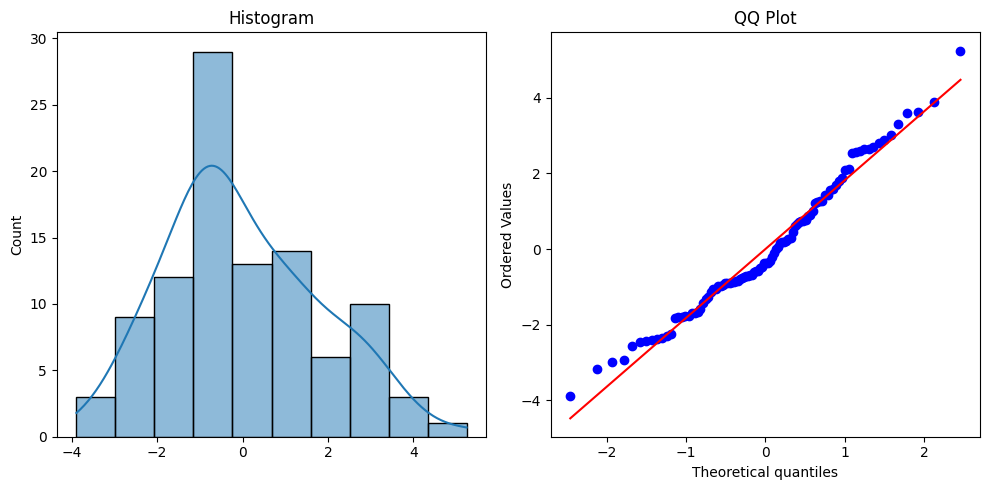

In [11]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(model.resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(model.resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

Apa kesimpulan Anda berdasarkan plot di atas?

1. Histogram residual

Histogram menunjukkan residual memiliki bentuk yang cukup menyerupai distribusi normal, dengan konsentrasi terbesar berada di sekitar nilai 0. Namun, distribusinya sedikit miring ke kanan dan terdapat beberapa residual yang cukup ekstrem.

2. QQ Plot

Pada QQ plot, sebagian besar titik berada cukup dekat dengan garis diagonal, terutama di bagian tengah. Namun, pada bagian ujung (tail) terlihat beberapa titik menyimpang dari garis, terutama pada ekor kanan.

Hal ini menunjukkan bahwa residual cukup mendekati distribusi normal, meskipun tidak sempurna pada bagian ekornya.

In [12]:
# Uji Shapiro-Wilk
shapiro_stat, shapiro_p_value = stats.shapiro(model.resid)
print(f"Shapiro-Wilk Test: Statistics = {shapiro_stat}, p-value = {shapiro_p_value}")

Shapiro-Wilk Test: Statistics = 0.9776104776943954, p-value = 0.08644202474174717


Apakah kesimpulan Anda dari nilai uji Shapiro Wilk sama dengan kesimpulan Anda berdasarkan plot?

$$W=0.9776$$
$$ p\text{-value}=0.0864 $$

Dengan taraf signifikansi \(\alpha=0.05\):

$p{-value}=0.0864 > 0.05$
sehingga H₀ tidak ditolak.
H₀ menyatakan bahwa residual berdistribusi normal.

## **Kecenderungan Kuadratik**

Deret dikatakan memiliki kecenderungan kuadratik dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t+\beta_2t^2$


In [15]:
# Menentukan parameter simulasi
np.random.seed(1011)
n_periods = 120
beta_0, beta_1, beta_2= 50+11, 0.5*11, 0.02*11
noise = np.random.normal(0, 10, n_periods)
time = np.arange(n_periods)

# Membuat komponen kuadratik
quadratic_component = beta_0 + beta_1 * time + beta_2 * time**2

# Menambahkan noise untuk membuat data lebih realistis
data = quadratic_component + noise

# Membuat DataFrame
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')
df_quad = pd.DataFrame({'Date': dates, 'Value': data})

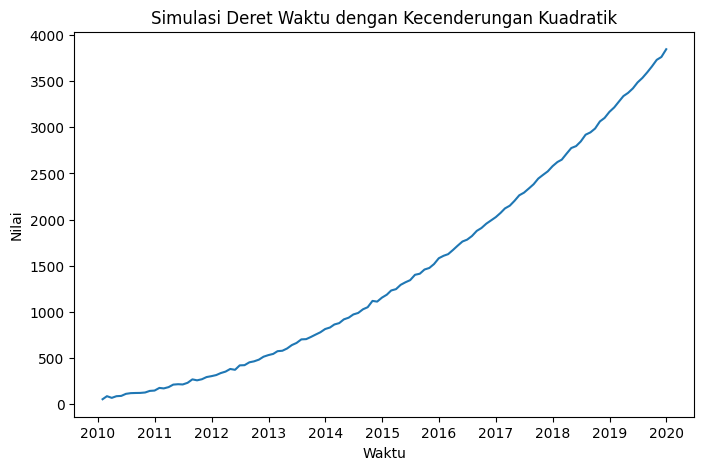

In [16]:
# Plot hasil simulasi deret waktu dengan kecenderungan kuadratik
plt.figure(figsize=(8, 5))
plt.plot(df_quad.Date, df_quad['Value'])
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.show()

Apa interpretasi Anda terhadap deret? Apa perbedaan pola yang terlihat dalam deret dibandingkan plot deret pada pola kecenderungan linear?

Terlihat bahwa nilai deret terus meningkat seiring bertambahnya waktu, tetapi kenaikannya tidak konstan. Pada awal periode, kenaikan nilai relatif lambat, kemudian semakin lama kenaikannya semakin cepat.

Bentuk kurva yang melengkung ke atas (cekung ke atas) menunjukkan adanya kecenderungan kuadratik positif.

In [18]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = np.column_stack((time, time**2))
X = sm.add_constant(X)
Y = data


# Buat dan jalankan model regresi
model_quad = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model_quad.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 8.124e+05
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          4.53e-243
Time:                        14:15:26   Log-Likelihood:                -440.66
No. Observations:                 120   AIC:                             887.3
Df Residuals:                     117   BIC:                             895.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         62.6813      2.597     24.140      0.0

Model yang dipaskan:

$$ \hat y = 62.6813 + 5.47199x_1 + 0.2200x_2 $$

dengan $x_2$ kemungkinan merupakan kuadrat waktu $(Time^2)$.
Parameter	Estimasi
Intercept	62.6813
$x_1$	5.47199
$x_2$	0.2200

Ketiga parameter memiliki p-value < 0.001, sehingga baik intercept, komponen linear, maupun komponen kuadratik berpengaruh signifikan terhadap $y$.

Yang paling penting adalah koefisien $x_2 = 0.2200$ yang positif. Ini menunjukkan adanya kecenderungan kuadratik yang meningkat, sesuai dengan grafik sebelumnya yang semakin curam.

Nilai $R^2$ dan Adjusted $R^2$ sebesar 1,000 menunjukkan bahwa model mampu menjelaskan hampir seluruh variasi data. Selain itu, nilai Durbin-Watson sebesar 2,261 dan hasil uji Jarque-Bera dengan p-value 0,276 menunjukkan bahwa residual tidak menunjukkan masalah autokorelasi yang kuat maupun penyimpangan normalitas yang signifikan. Dengan demikian, model regresi kuadratik yang dipaskan dapat dikatakan sangat baik dalam menggambarkan pola deret tersebut.


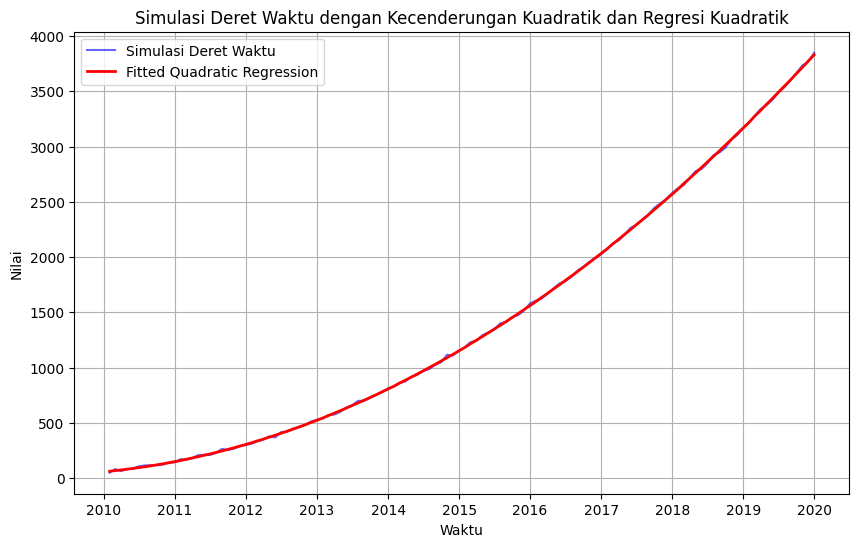

In [19]:
# Prediksi menggunakan model yang sudah dilatih
data_pred = model_quad.predict(X)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(df_quad.Date, df_quad['Value'], label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(df_quad.Date, data_pred, label='Fitted Quadratic Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik dan Regresi Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.legend()
plt.grid(True)
plt.show()

**Cek apakah model regresi kuadratik yang dipaskan terhadap sudah memenuhi asumsi-asumsi model!**

**Apakah model yang dipaskan terhadap deret sudah tepat? Jelaskan jawaban Anda!**

Model regresi kuadratik yang dipaskan sudah tepat untuk menggambarkan deret karena mampu menangkap pola kuadratik dengan sangat baik. Hal ini terlihat dari garis fitted yang hampir berimpit dengan deret asli dan nilai \(R^2=1.000\). Hasil pemeriksaan residual juga menunjukkan bahwa residual berdistribusi mendekati normal dan tidak menunjukkan autokorelasi yang kuat. Dengan demikian, model regresi kuadratik dapat dikatakan sesuai dengan pola deret dan asumsi-asumsi model secara umum telah terpenuhi.

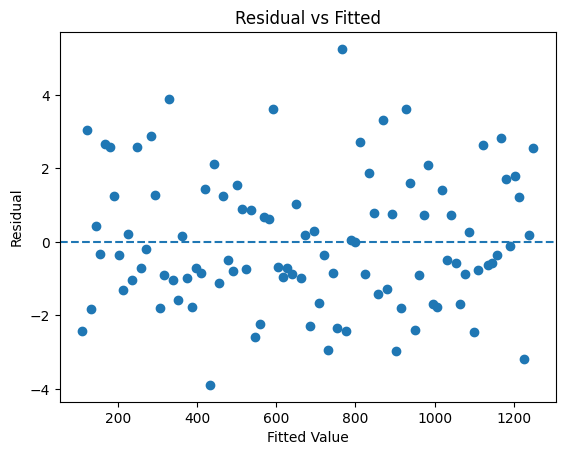

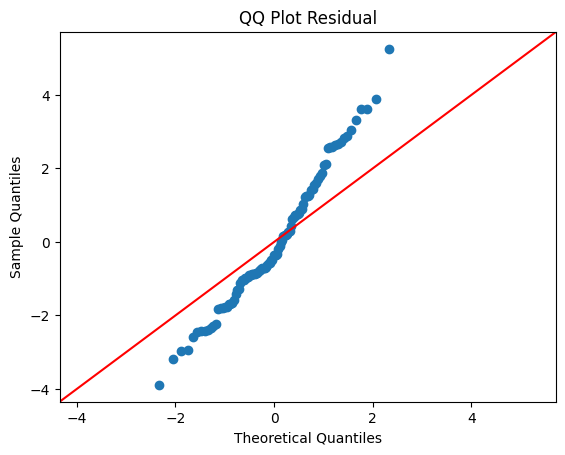

Shapiro-Wilk: ShapiroResult(statistic=np.float64(0.9776104776943954), pvalue=np.float64(0.08644202474174717))
Breusch-Pagan: (np.float64(0.0008707334829716196), np.float64(0.9764592843292387), np.float64(0.0008533262435069263), np.float64(0.9767551180236166))
Ljung-Box:
      lb_stat  lb_pvalue
1    3.884175   0.048743
5    7.713937   0.172722
10   8.566846   0.573644
20  16.063703   0.712664


In [20]:
# Cek asumsi regresi kuadratik

import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import shapiro
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox

resid = model.resid
fitted = model.fittedvalues

# 1. Residual vs Fitted
plt.scatter(fitted, resid)
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted Value")
plt.ylabel("Residual")
plt.title("Residual vs Fitted")
plt.show()

# 2. QQ Plot
sm.qqplot(resid, line="45")
plt.title("QQ Plot Residual")
plt.show()

# 3. Shapiro-Wilk
print("Shapiro-Wilk:", shapiro(resid))

# 4. Breusch-Pagan
print("Breusch-Pagan:", het_breuschpagan(resid, model.model.exog))

# 5. Ljung-Box
print("Ljung-Box:")
print(acorr_ljungbox(resid, lags=[1, 5, 10, 20], return_df=True))

1. Normalitas residual — Shapiro-Wilk
$$ p\text{-value}=0.0864>0.05 $$

H₀ tidak ditolak, sehingga residual dapat dianggap berdistribusi normal. Ini juga cukup didukung oleh QQ plot, meskipun ada penyimpangan di bagian ekor.

2. Homoskedastisitas — Breusch-Pagan
$$ p\text{-value}=0.9765>0.05 $$

H₀ tidak ditolak, sehingga tidak terdapat heteroskedastisitas. Varians residual dapat dianggap konstan.

Plot Residual vs Fitted juga menunjukkan residual tersebar di sekitar nol tanpa pola kipas yang jelas.

3. Autokorelasi — Ljung-Box

Lag 1: $p=0.0487< 0.05$  ada indikasi autokorelasi pada lag 1.

Lag 5: $p=0.1727>0.05$

Lag 10: $p=0.5736>0.05$

Lag 20: $p=0.7127>0.05$

Jadi, hanya lag 1 yang menunjukkan indikasi autokorelasi, sedangkan pada lag yang lebih panjang tidak terdapat bukti autokorelasi yang signifikan.

## Kecenderungan Musiman/Siklik

Misalkan suatu deret waktu memiliki nilaitengah $\mu_t$ yang didefinisikan sebagai berikut:

$\mu_t=\beta_0+\beta_1 cos(2\pi f t)+\beta_2 sin(2\pi ft)$

Deret tersebut memiliki kecenderungan kosinus yang berpola musiman.

Bentuk lain fungsi nilaitengah dari kecenderungan musiman (misalnya untuk data bulanan) adalah $\mu_t$ berupa suatu konstanta sejumlah 12 yang nilai berbeda-beda. Nilai ini diinterpretasikan sebagai nilai harapan rata-rata data untuk masing-masing bulan, atau dapat dituliskan sebagai berikut:

$\mu_t=\beta_1$ , untuk $t=1,13,25,...$
       
$\mu_t=\beta_2$ , untuk $t=2,14,26,...$

$.$

$.$

$.$

$\mu_t=\beta_{12}$ , $untuk t=12,24,36,...$


In [21]:
# Menentukan parameter simulasi
np.random.seed(1011)
n_periods = 120
beta0, beta1, beta2=50+11,-25*11, -2*11
freq=1/12

# Membuat komponen musiman
time = np.arange(n_periods)
seasonal_component = beta0+ beta1*np.cos(2*np.pi*time*freq)+beta2*np.sin(2*np.pi*time*freq)

# Menambahkan noise acak
noise = np.random.normal(0, 2, n_periods)

# Simulasi data dengan hanya komponen musiman dan noise (tanpa tren)
data = seasonal_component + noise

# Membuat index waktu (misalnya menggunakan bulan)
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')

# Membuat DataFrame untuk mempermudah analisis dan visualisasi
df_seasonal = pd.DataFrame({'Date': dates, 'Value': data})


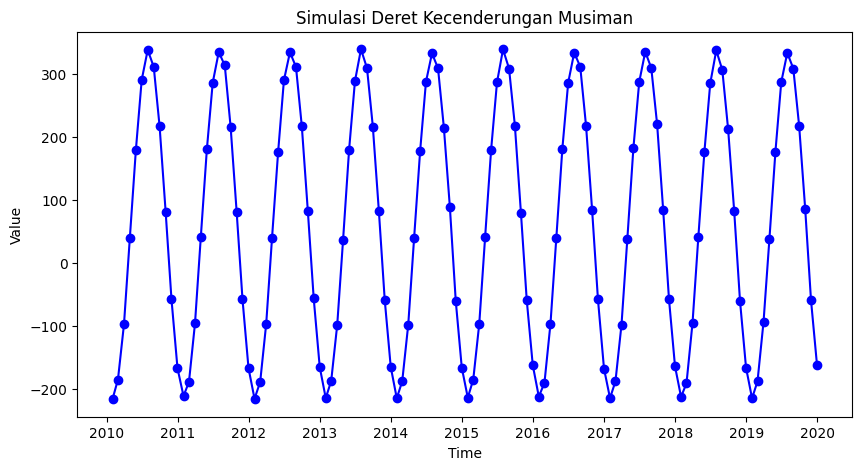

In [22]:
# Plot data deret waktu
plt.figure(figsize=(10, 5))
plt.plot(df_seasonal["Date"], df_seasonal["Value"],'-ob')
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Simulasi Deret Kecenderungan Musiman")
plt.show()


Misalkan deret tersebut merupakan deret musiman dengan periode musiman 12. Bagaimana Anda menginterpretasikan pola yang terlihat dalam deret tersebut?

Berdasarkan plot, deret menunjukkan pola musiman dengan periode 12. Nilai deret mengalami kenaikan dan penurunan secara berulang dengan pola yang relatif sama setiap 12 periode. Karena data merupakan data bulanan dan periode musimannya 12, pola tersebut menunjukkan adanya pola musiman tahunan. Terdapat periode tertentu dengan nilai yang cenderung tinggi dan periode lainnya dengan nilai yang cenderung rendah, kemudian pola tersebut berulang pada tahun berikutnya. Amplitudo fluktuasi musiman relatif stabil dari waktu ke waktu.

In [23]:
# membuat dummy variabel musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
musim= Seasonality(12, initial_period=1).in_sample(df_seasonal.index)
musim.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [24]:
musim

,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
116,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
117,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
118,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [25]:
# pengepasan model regresi tanpa intercept
musiman=sm.OLS(df_seasonal["Value"],musim).fit()

In [26]:
print(musiman.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.105e+05
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          2.53e-213
Time:                        14:18:00   Log-Likelihood:                -243.36
No. Observations:                 120   AIC:                             510.7
Df Residuals:                     108   BIC:                             544.2
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari     -214.0522      0.613   -349.240      0.0

Bagaimana interpretasi dari hasil tersebut?
1. Kualitas Model

Nilai:

$$ R^2 = 1.000 $$

dan

$$ Adjusted\ R^2 = 1.000 $$

Artinya, sekitar 100% variasi nilai deret dapat dijelaskan oleh pola bulanan dalam model. Hal ini menunjukkan bahwa model mampu menangkap pola data dengan sangat baik, sehingga variasi yang tidak dijelaskan oleh model sangat kecil.

Selain itu, diperoleh:

$$ p\text{-value F-statistic}=2.53\times10^{-213}< 0.05 $$

sehingga model secara keseluruhan signifikan. Dengan demikian, variabel bulan secara bersama-sama berpengaruh signifikan dalam menjelaskan variasi nilai deret.

2. Pola Musiman

Seluruh koefisien bulan memiliki:

$$ p\text{-value}< 0.001 $$

sehingga terdapat perbedaan yang signifikan antarbulan. Hal ini menunjukkan adanya pola musiman yang sangat kuat dalam deret.

Berdasarkan koefisiennya, pola nilai meningkat dari awal tahun hingga pertengahan tahun:

Januari: koefisien sekitar −214,05

Februari: −187,95

Maret: −96,32

April: 39,75

Mei: 179,21

Juni: 287,91

Juli: 336,36 → puncak

Agustus: 310,35

September: 217,03

Oktober: 83,54

November: −58,13

Desember: −165,28

Dengan demikian, pola musiman menunjukkan kenaikan nilai dari awal tahun hingga mencapai puncak pada Juli, kemudian mengalami penurunan secara bertahap hingga akhir tahun. Nilai terendah berdasarkan koefisien bulanan terdapat pada Januari, sedangkan Juli merupakan bulan dengan efek musiman tertinggi.

Catatan: koefisien bulan pada output ini merupakan efek/kontribusi masing-masing bulan dalam model, sehingga jangan langsung dibaca sebagai nilai aktual deret seperti “Januari = 46,95”. Nilai aktual perlu dilihat dari prediksi/intercept atau hasil model lengkapnya.

3. Asumsi Residual

Normalitas residual

Berdasarkan uji Jarque-Bera diperoleh:

$$ p=0.415>0.05 $$

Sehingga tidak terdapat bukti yang cukup untuk menolak asumsi normalitas residual. Dengan kata lain, residual dapat dianggap berdistribusi normal.

Nilai Skewness = 0.215 juga menunjukkan residual relatif simetris, sedangkan Kurtosis = 2.591 cukup dekat dengan nilai 3 yang merupakan karakteristik distribusi normal.

Autokorelasi residual

Nilai:

$$ DW=2.175 $$

Nilai Durbin-Watson yang mendekati 2 menunjukkan bahwa tidak terdapat indikasi autokorelasi residual yang kuat. Dengan demikian, residual relatif independen.

In [27]:
# Analisis Sisaan
# mendapatkan sisaan terbakukan
influence=musiman.get_influence()
std_resid=influence.resid_studentized_internal

mapping={1:'$J$',2:'$F$',3:'$M$',
 4:'$A$',5:'$M$',6:'$J$',
 7:'$J$',8:'$A$',9:'$S$',
 10:'$O$',11:'$N$',12:'$D$'}

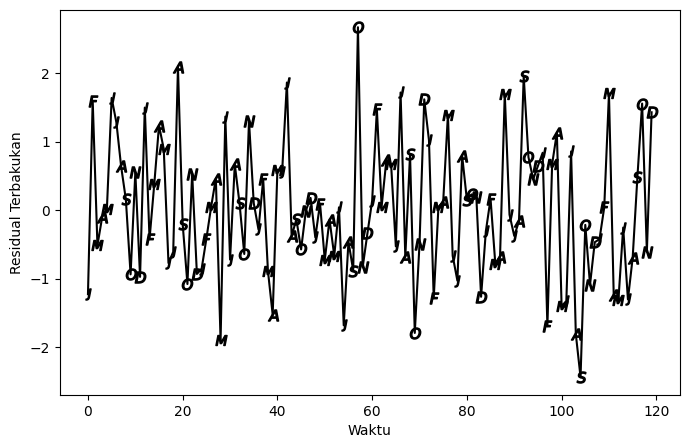

In [28]:
#memetakan sisaan dengan bentuk plot sesuai simbol bulan/musim
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
 plt.plot(i, std_resid[i], marker=mapping[i%12+1],
 color='black', markersize=8)

#membuat plot sisaan terbakukan
plt.plot(std_resid, color='black')
plt.xlabel('Waktu'), plt.ylabel('Residual Terbakukan')
plt.show()


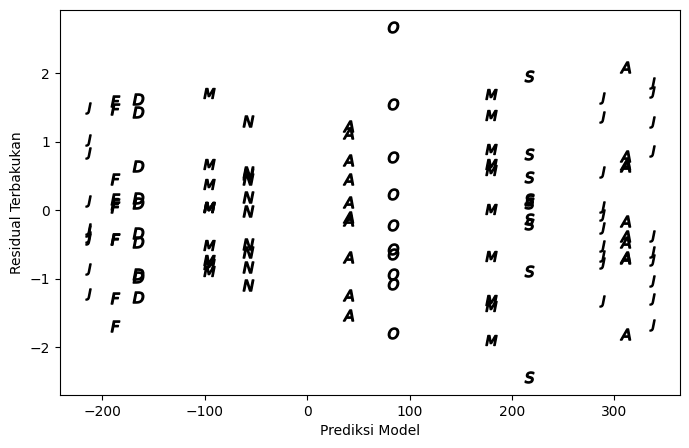

In [29]:
# membuat plot fittedvalues dengan residual terbakukan dengan simbol bulan
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
  plt.plot(musiman.fittedvalues.values[i],
           std_resid[i], marker=mapping[i%12+1],
           color='black', markersize=8)
plt.xlabel('Prediksi Model'),plt.ylabel('Residual Terbakukan')
plt.show()

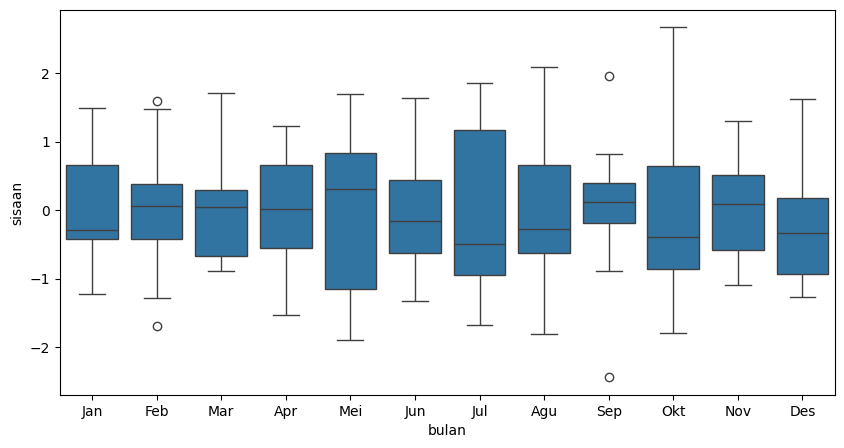

In [30]:
#membuat list daftar bulan
bulan=['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']*10

#membuat dataframe untuk mengidentifikasi sisaan dan periode bulannya
box_sisaan=pd.DataFrame(zip(bulan[:-1], std_resid),
columns=['bulan','sisaan'])

#membuat boxplot per buln
plt.figure(figsize=(10,5))
sns.boxplot(x='bulan',y='sisaan',data=box_sisaan)
plt.show()

Bagaimana interpretasi Anda terhadap tiga plot di atas?

1. Plot residual terbakukan terhadap waktu

Pada plot pertama, residual terbakukan berfluktuasi di sekitar garis nol dan tidak menunjukkan pola tertentu yang konsisten dari waktu ke waktu. Residual kadang positif dan kadang negatif, dengan sebagian besar berada pada kisaran sekitar -2 sampai 2.

Tidak terlihat adanya tren atau pola musiman yang jelas pada residual. Ini menunjukkan bahwa komponen musiman utama sudah berhasil ditangkap oleh model.

Kesimpulan: residual tidak menunjukkan pola sistematis terhadap waktu, sehingga model sudah cukup baik dalam menangkap pola yang terdapat pada deret.

2. Plot residual terbakukan terhadap prediksi model

Pada plot kedua, residual tersebar di sekitar nilai nol pada berbagai tingkat nilai prediksi. Tidak terlihat pola seperti bentuk kipas (funnel) atau pola melengkung yang jelas.

Sebaran residual juga relatif acak, meskipun terdapat beberapa nilai residual yang cukup besar.

Kesimpulan: tidak terlihat adanya pola sistematis antara residual dan nilai prediksi, sehingga tidak ada indikasi kuat adanya masalah heteroskedastisitas secara visual.

3. Boxplot residual berdasarkan bulan

Plot ketiga memperlihatkan distribusi residual untuk masing-masing bulan.

Secara umum, median residual setiap bulan berada cukup dekat dengan nol. Sebaran residual antarbulan memang berbeda-beda, tetapi tidak terlihat perbedaan yang sangat ekstrem secara umum. Beberapa bulan, seperti Februari, September, dan Oktober, memiliki titik yang cukup ekstrem (outlier).

Namun, keberadaan beberapa outlier tersebut tidak serta-merta menunjukkan bahwa model tidak tepat. Yang lebih penting adalah apakah residual menunjukkan pola musiman yang tersisa. Dari boxplot, tidak terlihat pola residual yang konsisten berdasarkan bulan.

Kesimpulan: residual pada masing-masing bulan secara umum masih berpusat di sekitar nol dan tidak menunjukkan pola musiman yang kuat. Terdapat beberapa outlier, tetapi secara keseluruhan pola residual masih cukup acak.


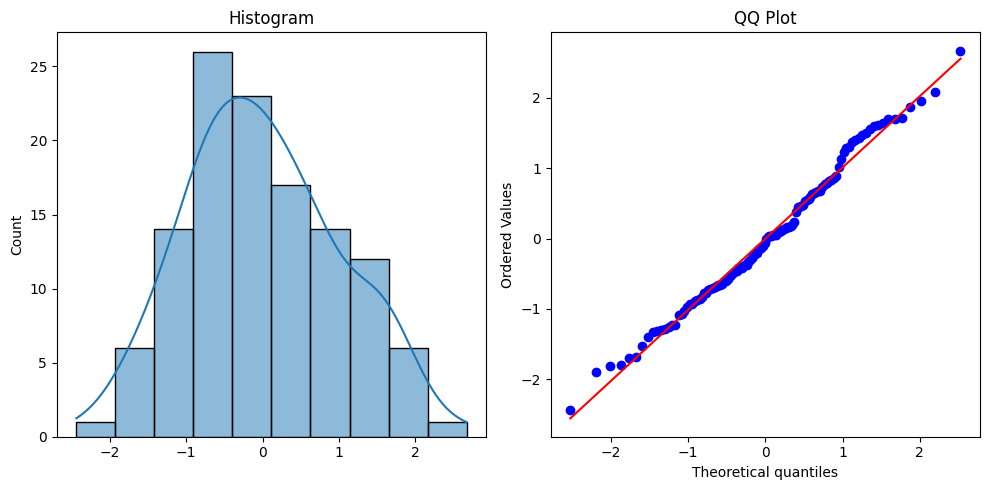

In [31]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(std_resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(std_resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

**Berdasarkan plot-plot tersebut apakah dapat dikatakan bahwa model yang dipaskan sudah tepat?**

**Hitunglah statistik uji untuk mengecek asumsi model**

Berdasarkan histogram dan QQ plot, residual model musiman secara umum mendekati distribusi normal. Sebagian besar titik pada QQ plot berada di sekitar garis diagonal dan histogram menunjukkan distribusi yang relatif simetris di sekitar nol. Dengan demikian, dari sisi normalitas residual, model dapat dikatakan sudah cukup baik.

In [ ]:
# hitung statistik uji untuk mengecek asumsi model tanpa intersep

In [32]:
# pengepasan model regresi dengan intersep
musiman_int=sm.OLS(df_seasonal["Value"],sm.add_constant(musim.iloc[:,1:])).fit()

In [33]:
print(musiman_int.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.105e+05
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          2.53e-213
Time:                        14:21:45   Log-Likelihood:                -243.36
No. Observations:                 120   AIC:                             510.7
Df Residuals:                     108   BIC:                             544.2
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -214.0522      0.613   -349.240      0.0

**Perhatikan hasil pengepasan model dengan intersep. Bandingkan hasilnya dengan pengepasan tanpa intersep. Bagaimana interpretasi model dengan intersep dibandingkan model tanpa intersep? Jelaskan cara memaknai nilai koefisien regresi yang diperoleh**!

1. Kesesuaian Model

Nilai:

$$ R^2=1.000,\qquad Adjusted\ R^2=1.000 $$

Artinya, sekitar 100% variasi Value dapat dijelaskan oleh pola bulanan yang dimasukkan ke dalam model. Nilai \(R^2\) dan Adjusted \(R^2\) yang sangat tinggi menunjukkan bahwa model memiliki kemampuan yang sangat baik dalam menjelaskan variasi data.

Model secara keseluruhan juga signifikan karena:

$$ p\text{-value F}=2.53\times10^{-213}< 0.05 $$

Sehingga dapat disimpulkan bahwa variabel bulan secara bersama-sama berpengaruh signifikan terhadap Value.

2. Interpretasi Model dengan Intersep

Pada model dengan intersep, Januari menjadi kategori acuan (reference category).

Nilai intersep:

$$ \beta_0=-214.0522 $$

menunjukkan nilai rata-rata Value yang diprediksi untuk bulan Januari.

Untuk bulan lainnya, nilai koefisien menunjukkan perbedaan nilai bulan tersebut dibandingkan dengan Januari.

Contohnya:

Februari

$$ \beta_{\text{Februari}}=26.1018 $$

Artinya, nilai Value pada Februari diperkirakan 26.10 lebih tinggi dibandingkan Januari.

Nilai prediksi Februari:

$$ -214.0522+26.1018=-187.9504 $$

Juni

$$ \beta_{\text{Juni}}=501.9650 $$

Artinya, nilai Value pada Juni diperkirakan 501.97 lebih tinggi dibandingkan Januari.

Nilai prediksi Juni:

$$ -214.0522+501.9650=287.9128 $$

Juli

$$ \beta_{\text{Juli}}=550.4107 $$

Artinya, nilai Value pada Juli diperkirakan 550.41 lebih tinggi dibandingkan Januari, sehingga Juli memiliki nilai prediksi tertinggi.

Nilai prediksi Juli:

$$ -214.0522+550.4107=336.3585 $$

Desember

$$ \beta_{\text{Desember}}=48.7689 $$

Artinya, nilai Value pada Desember diperkirakan 48.77 lebih tinggi dibandingkan Januari.

Nilai prediksi Desember:

$$ -214.0522+48.7689=-165.2833 $$

Jadi, semua koefisien bulan bernilai positif karena seluruh bulan tersebut memiliki nilai yang lebih tinggi daripada Januari.

Selain itu, seluruh bulan memiliki:

$$ p\text{-value}< 0.001 $$

sehingga seluruh bulan berbeda secara signifikan dari Januari.

3. Pola Musiman

Berdasarkan nilai prediksi setiap bulan, terlihat pola musiman yang jelas.

Nilai meningkat dari:

$$ Januari \rightarrow Februari \rightarrow Maret \rightarrow \cdots \rightarrow Juli $$

dan mencapai puncak pada:

$$ Juli=336.36 $$

Kemudian nilai menurun secara bertahap:

$$ Agustus \rightarrow September \rightarrow \cdots \rightarrow Desember $$

dengan nilai Desember sekitar:

$$ Desember=-165.28 $$

Dengan demikian, pola musiman menunjukkan peningkatan nilai dari awal tahun hingga mencapai puncak pada Juli, kemudian mengalami penurunan hingga akhir tahun.

4. Makna Koefisien Regresi

Hal yang penting adalah jangan membaca koefisien bulan sebagai nilai aktual bulan tersebut.

Pada model dengan intersep:

$$ \text{Value}=\beta_0+\beta_1X_{\text{Feb}}+\cdots+\beta_{11}X_{\text{Des}} $$

Intersep merupakan nilai untuk Januari, sedangkan koefisien bulan merupakan selisih terhadap Januari.

Contohnya:

$$ \text{Juli}=\beta_0+\beta_{\text{Juli}} $$ $$ =-214.0522+550.4107 $$ $$ =336.3585 $$

Jadi, 550.4107 bukan nilai Value bulan Juli, tetapi selisih nilai Juli terhadap Januari.

5. Asumsi Residual

Normalitas residual

Berdasarkan uji Jarque-Bera:

$$ p=0.415>0.05 $$

sehingga tidak terdapat bukti yang cukup untuk menolak asumsi normalitas. Dengan demikian, residual dapat dianggap berdistribusi normal.

Autokorelasi residual

Nilai Durbin-Watson:

$$ DW=2.175 $$

Nilai yang mendekati 2 menunjukkan bahwa tidak terdapat indikasi autokorelasi residual yang kuat.

In [34]:
# uji asumsi model dengan intersep
from scipy.stats import shapiro
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox

resid = musiman_int.resid

# 1. Normalitas
print("Shapiro-Wilk:")
print(shapiro(resid))

# 2. Homoskedastisitas
print("\nBreusch-Pagan:")
print(het_breuschpagan(resid, musiman_int.model.exog))

# 3. Autokorelasi
print("\nLjung-Box:")
print(acorr_ljungbox(resid, lags=[1, 5, 10, 20], return_df=True))

Shapiro-Wilk:
ShapiroResult(statistic=np.float64(0.9887755501217776), pvalue=np.float64(0.4314704722892769))

Breusch-Pagan:
(np.float64(9.5643348314819), np.float64(0.5699476990921412), np.float64(0.8503084415905525), np.float64(0.5907329227676388))

Ljung-Box:
      lb_stat  lb_pvalue
1    1.282043   0.257519
5    4.819072   0.438358
10   6.043521   0.811594
20  25.172013   0.194929


1. Normalitas — Shapiro-Wilk
$$ p=0.4315>0.05 $$

H₀ tidak ditolak, sehingga residual berdistribusi normal.

2. Homoskedastisitas — Breusch-Pagan
$$ p=0.5699>0.05 $$

H₀ tidak ditolak, sehingga tidak terdapat heteroskedastisitas atau varians residual dapat dianggap konstan.

3. Autokorelasi — Ljung-Box

Semua p-value > 0,05:

Lag 1 = 0,2575

Lag 5 = 0,4384

Lag 10 = 0,8116

Lag 20 = 0,1949

Tidak terdapat autokorelasi residual yang signifikan.

## Kecenderungan Linear dan Musiman

In [36]:
# Parameter
np.random.seed(1011)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 0.5*11, 10*11 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=2, size=n)

# Gabungan semua komponen
series = trend + seasonality + noise


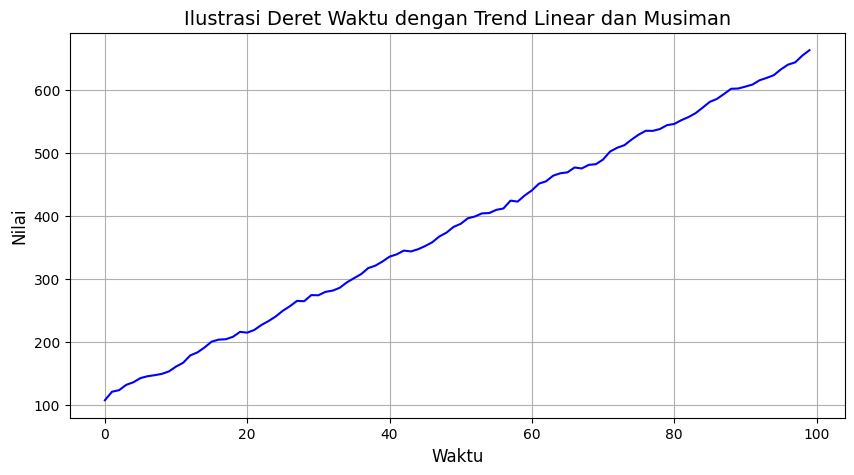

In [37]:
plt.figure(figsize=(10, 5))
plt.plot(x, series, color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman', fontsize=14)
plt.grid()
plt.show()

Untuk deret tersebut, dibutuhkan model yang mampu menangkap kecenderungan linear (tren) sekaligus kecenderungan musiman dalam deret. Salah satu model sederhana yang dapat digunakan adalah model regresi linear dengan variabel musiman.

yang nilainya hanya berkisar:

$$ -5 \leq Seasonality \leq 5 $$

dan noise hanya sekitar ± beberapa satuan.

Jadi keseluruhannya:

$$ Y_t= \underbrace{5.5t+110}_{\text{trend linear}} + \underbrace{5\sin(2\pi t/12)}_{\text{musiman}} + \underbrace{\epsilon_t}_{\text{noise}} $$

Trend meningkat sekitar 5,5 satuan setiap periode, sedangkan efek musiman hanya berkisar ±5 satuan. Oleh karena itu, ketika deret diplot, kecenderungan naik akibat trend linear tetap terlihat dominan, sementara gelombang musiman relatif lebih kecil.

Jadi, bukan berarti komponen musiman tidak ada. Komponen musiman tetap ada, tetapi pengaruhnya lebih kecil dibandingkan kecenderungan trend linear.

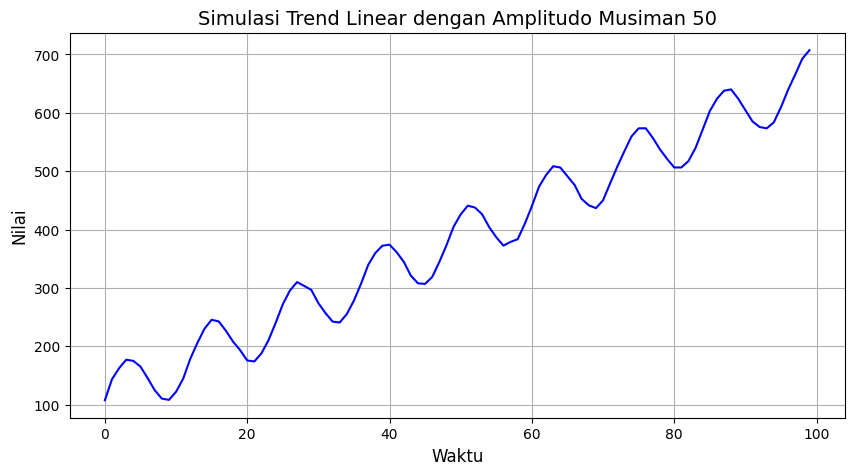

In [38]:
# Simulasi percobaan jika amplitudo diubah

np.random.seed(1011)
n_amp = 100
x_amp = np.arange(n_amp)

# Komponen trend linear
a_amp, b_amp = 0.5 * 11, 10 * 11
trend_amp = a_amp * x_amp + b_amp

# Komponen musiman dengan amplitudo 50
seasonality_amp = 50 * np.sin(2 * np.pi * x_amp / 12)

# Noise acak
noise_amp = np.random.normal(scale=2, size=n_amp)

# Gabungan semua komponen
series_amp = trend_amp + seasonality_amp + noise_amp

# Plot
plt.figure(figsize=(10, 5))
plt.plot(x_amp, series_amp, color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Simulasi Trend Linear dengan Amplitudo Musiman 50', fontsize=14)
plt.grid()
plt.show()

karena amplitudonya diubah dari 5 - 50, pola musiman akan jauh lebih terlihat meskipun trend linearnya tetap sama.

**catatan : tetap menggunakan data yang awal**

In [39]:
# mengubah data menjadi format dataframe
df_mix = pd.DataFrame(series, columns=['Value'])

# mengekstrak komponen musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
season= Seasonality(12, initial_period=1).in_sample(df_mix.index)
season.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [40]:
season['period']=x

model_mix=sm.OLS(series,season).fit()

In [41]:
print(model_mix.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 6.180e+04
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.87e-165
Time:                        14:26:09   Log-Likelihood:                -196.09
No. Observations:                 100   AIC:                             418.2
Df Residuals:                      87   BIC:                             452.0
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari      109.9587      0.687    160.066      0.0

Bagaimana cara menginterpretasikan nilai koefisien regresi yang diperoleh dalam model regresi tersebut?

1. Kesesuaian model secara keseluruhan

Diperoleh:

$$ R^2=1.000 $$

dan

$$ Adjusted\ R^2=1.000 $$

Artinya, model mampu menjelaskan sekitar 100% variasi nilai deret. Hal ini menunjukkan bahwa kombinasi trend linear dan pola musiman dalam model sangat sesuai dengan data simulasi.

Model juga signifikan secara keseluruhan karena:

$$ p\text{-value F}=1.87\times10^{-165}< 0.05 $$

Sehingga dapat disimpulkan bahwa model regresi secara keseluruhan signifikan dalam menjelaskan variasi deret.

2. Interpretasi parameter trend

Pada simulasi, parameter trend yang digunakan adalah:

$$ a=0.5\times11=5.5 $$

dan

$$ b=10\times11=110 $$

sehingga komponen trendnya adalah:

$$ Trend_t=5.5t+110 $$

Dari hasil regresi diperoleh koefisien:

$$ \hat{\beta}_{period}=5.5016 $$

dengan:

$$ p< 0.001 $$

Nilai estimasi \(5.5016\) sangat dekat dengan nilai sebenarnya, yaitu \(5.5\).

Artinya, setiap periode waktu bertambah satu satuan, nilai deret meningkat rata-rata sekitar 5.5 satuan, dengan tetap mempertimbangkan adanya komponen musiman.

Dengan demikian, model berhasil menangkap kecenderungan trend linear dalam data dengan sangat baik.

3. Interpretasi koefisien bulanan

Pada model ini tidak terdapat intersep (const), tetapi seluruh 12 bulan dimasukkan sebagai variabel dummy.

Karena itu, koefisien masing-masing bulan tidak dibaca sebagai selisih terhadap Januari.

Koefisien bulan dapat dipandang sebagai nilai dasar/level untuk masing-masing bulan, sebelum ditambahkan dengan pengaruh trend period.

Hasil estimasinya:

Bulan	Koefisien

Januari	109.9587

Februari	112.6213

Maret	113.1327

April	115.9173

Mei	114.6404

Juni	112.5449

Juli	110.3853

Agustus	108.1925

September	105.5163

Oktober	105.1491

November	105.2996

Desember	108.0693

Terlihat pola:

naik → mencapai puncak → turun → mencapai lembah → naik kembali.

Koefisien tertinggi terdapat pada:

$$ April=115.9173 $$

sedangkan yang terendah:

$$ Oktober=105.1491 $$

Pola tersebut sesuai dengan komponen musiman yang digunakan dalam simulasi:

$$ Seasonality=5\sin\left(\frac{2\pi t}{12}\right) $$

dengan periode:

$$ 12 $$

dan amplitudo:

$$ 5 $$

Jadi, efek musiman bergerak sekitar ±5 satuan di sekitar level dasar 110.

Contohnya, secara teoritis:

$$ Januari=110+5\sin(0)=110 $$

sedangkan sekitar April:

$$ April\approx110+5=115 $$

dan sekitar Oktober:

$$ Oktober\approx110-5=105 $$

Hasil regresi sangat dekat dengan pola tersebut.

Catatan penting: karena model tidak menggunakan intersep dan seluruh bulan dimasukkan sebagai dummy, koefisien Januari 109.9587 bukan "intersep" dalam arti koefisien const, melainkan koefisien dummy Januari. Dalam model ini, masing-masing koefisien bulan membawa level dasar sekaligus efek musiman bulan tersebut.

4. Interpretasi signifikansi parameter

Seluruh parameter pada output memiliki:

$$ p< 0.001 $$

sehingga seluruh parameter bulan dan parameter period signifikan secara statistik.

Khusus untuk trend:

$$ \hat{\beta}_{period}=5.5016,\qquad p< 0.001 $$

menunjukkan bahwa terdapat kecenderungan peningkatan nilai yang sangat signifikan seiring bertambahnya waktu.

5. Pemeriksaan residual
Normalitas

Berdasarkan uji Jarque-Bera:

$$ p=0.398>0.05 $$

dan uji Omnibus:

$$ p=0.364>0.05 $$

Sehingga tidak terdapat bukti yang cukup untuk menyatakan residual tidak normal. Dengan demikian, residual dapat dianggap berdistribusi normal.

Autokorelasi

Nilai Durbin-Watson:

$$ DW=2.329 $$

Nilai tersebut cukup dekat dengan 2, sehingga tidak menunjukkan adanya autokorelasi residual yang kuat.

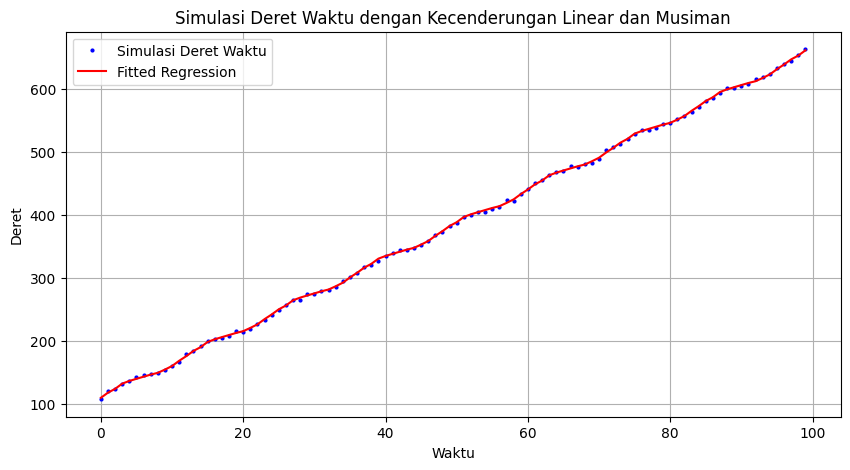

In [42]:
# Prediksi menggunakan model yang sudah dilatih
pred_mix = model_mix.predict(season)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 5))

plt.plot(x, series, 'b.', label='Simulasi Deret Waktu', markersize=4)
plt.plot(x, pred_mix, 'r-', label='Fitted Regression')

plt.xlabel('Waktu')
plt.ylabel('Deret')
plt.title('Simulasi Deret Waktu dengan Kecenderungan Linear dan Musiman')
plt.legend()
plt.grid()
plt.show()

Lakukan pengecekan asumsi model! Jelaskan apakah hasil menunjukkan ada pelanggaran asumsi dalam model!

In [ ]:
# uji asumsi model

Saat melihat plot dari suatu deret, terkadang kita tidak yakin komponen apa saja yang ada dalam deret. Misalkan, apakah deret tidak memuat tren? apakah ada tren? apakah ada komponen musiman? Untuk memastikan komponen apa saja yang ada dalam suatu deret, dapat dilakukan dengan dekomposisi deret. Dekomposisi deret bertujuan menguraikan deret menjadi 3 komponen, yaitu tren, musiman, dan noise.

In [43]:
from statsmodels.tsa.seasonal import seasonal_decompose
# Membuat DataFrame
df = pd.DataFrame({
    "Time": pd.date_range("2017-01-01", periods=len(series), freq="ME"),
    "Value": series
})

result = seasonal_decompose(
    df['Value'],
    model='additive',
    period=12
)


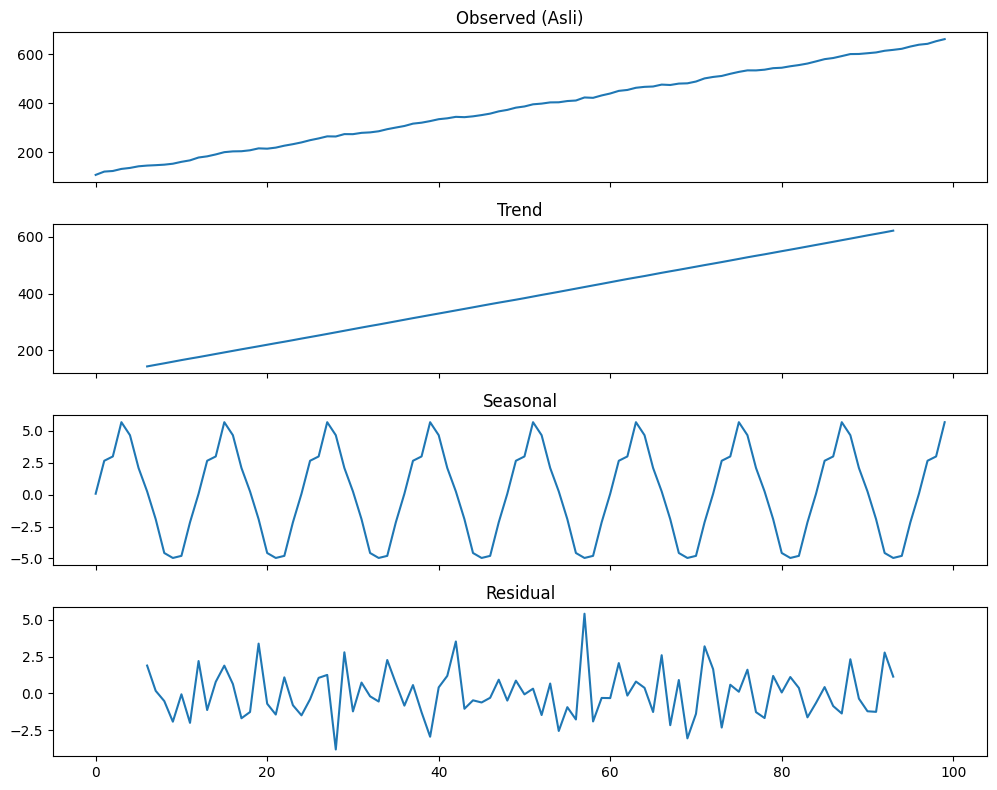

In [44]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

**Bagaimana interpretasi hasil dekomposisi deret tersebut?**

Hasil dekomposisi deret waktu dapat diinterpretasikan sebagai berikut:

Observed (Asli): menunjukkan deret data yang
memiliki kecenderungan meningkat dari waktu ke waktu dengan sedikit pola naik-turun.

Trend: menunjukkan pola kenaikan yang hampir linear, sehingga dapat dikatakan bahwa deret memiliki trend positif yang kuat.

Seasonal: terlihat pola yang berulang setiap 12 periode, dengan fluktuasi sekitar −5 sampai +5. Hal ini menunjukkan adanya pola musiman tahunan yang konsisten.

Residual: berfluktuasi di sekitar nilai nol dan tidak menunjukkan pola yang sistematis. Artinya, setelah pengaruh trend dan musiman dihilangkan, sisa variasi data relatif acak dan terutama berasal dari noise.

Kesimpulan: Deret waktu tersebut didominasi oleh trend linear positif, disertai pola musiman periode 12 yang cukup jelas, sedangkan residual relatif kecil dan acak. Jadi, dekomposisi berhasil memisahkan komponen trend, musiman, dan residual dengan baik

In [45]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear dan musiman
from statsmodels.tsa.seasonal import seasonal_decompose
result_mix = seasonal_decompose(df_mix['Value'], model='additive', period=12)

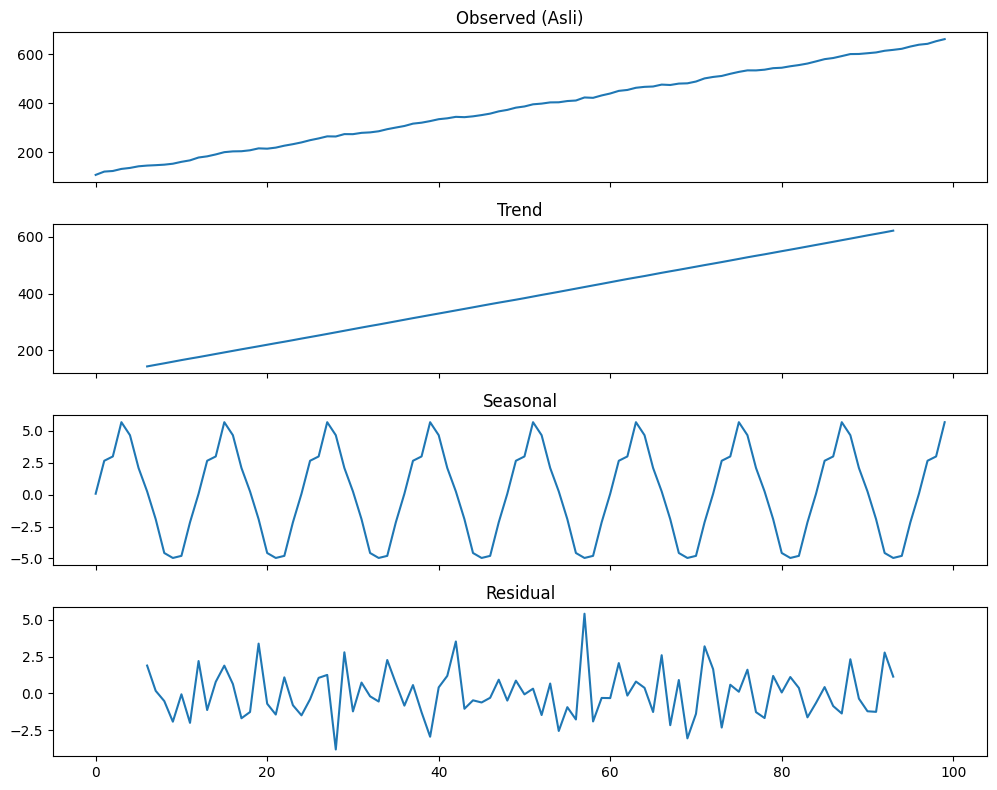

In [46]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result_mix.observed.plot(ax=axes[0], title='Observed (Asli)')
result_mix.trend.plot(ax=axes[1], title='Trend')
result_mix.seasonal.plot(ax=axes[2], title='Seasonal')
result_mix.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()


Bagaimana interpretasi hasil dekomposisi deret tersebut?

Deret memiliki trend linear positif yang kuat, dengan pola musiman yang berulang setiap 12 periode dan amplitudo sekitar ±5. Setelah komponen trend dan musiman dipisahkan, residual berfluktuasi di sekitar nol dan tidak menunjukkan pola sistematis yang jelas.

Ketika melakukan dekoposisi deret, perlu diperhatikan bahwa terdapat 2 jenis model untuk dekomposisi, yaitu model `Aditif` dan `multiplikatif`.

- Model `aditif` digunakan jika ragam deret relatif konstan atau kecil

- Model `multiplikatif` digunakan jika ragam deret besar

In [48]:
# ilustrasi untuk deret multiplikatif
# Parameter
np.random.seed(1011)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 0.05*11, 10*11 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 1+ 0.5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=0.2, size=n)

# Gabungan semua komponen
series_multi = trend*seasonality + noise

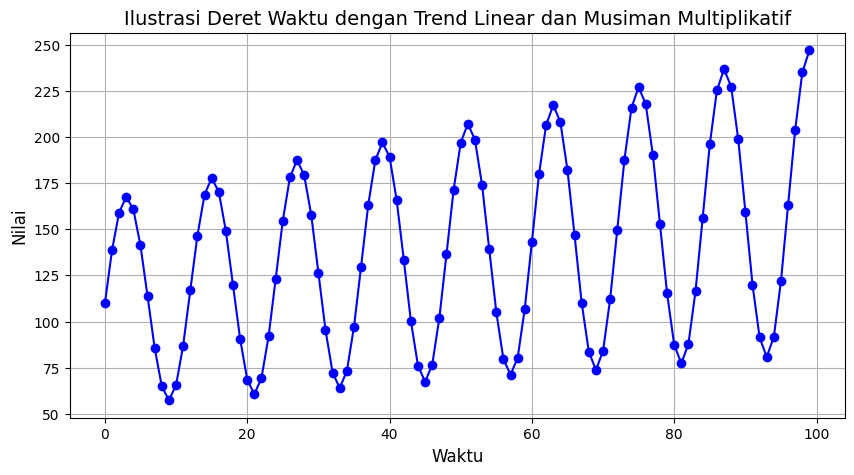

In [50]:
plt.figure(figsize=(10, 5))
plt.plot(x, series_multi, color='b', marker='o')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman Multiplikatif', fontsize=14)
plt.grid()
plt.show()

Pada grafik terlihat beberapa karakteristik:

1. Tren meningkat
Secara umum, nilai deret waktu terus meningkat dari kiri ke kanan. Pada awal periode, nilai deret berada pada kisaran 60–180, sedangkan pada akhir periode meningkat hingga sekitar 80–250. Hal ini menunjukkan adanya tren naik (upward trend) dalam deret.

2. Pola musiman
Terlihat pola naik dan turun yang berulang secara teratur sepanjang waktu. Puncak dan lembah muncul secara berulang dengan jarak sekitar 12 periode, sehingga menunjukkan adanya pola musiman dengan periode 12.

3. Musiman bersifat multiplikatif
Berbeda dengan model musiman aditif, pada grafik ini besar fluktuasi musiman tidak konstan. Ketika level deret semakin tinggi akibat tren, jarak antara titik puncak dan lembah juga cenderung semakin besar.

Dengan kata lain, besarnya efek musiman bergantung pada level deret. Pada awal periode, fluktuasi relatif lebih kecil, sedangkan pada periode-periode akhir ketika nilai deret semakin tinggi, fluktuasi musiman menjadi lebih besar.

Jadi, karakteristik utama grafik adalah tren meningkat yang disertai pola musiman berulang dengan amplitudo yang semakin besar, yang merupakan ciri dari deret waktu dengan komponen musiman multiplikatif.

Dekomposisi dengan model multiplikatif hanya bisa dilakukan untuk deret dengan nilai >0, sehingga jika deret memiliki nilai 0 atau negatif maka deret perlu ditransformasi.

In [51]:
#  Dekomposisi dengan model multiplikatif
# mengubah data menjadi format dataframe
df_multi = pd.DataFrame(series_multi, columns=['Value'])

from statsmodels.tsa.seasonal import seasonal_decompose
result_multi = seasonal_decompose(df_multi['Value'], model='multiplicative', period=12)

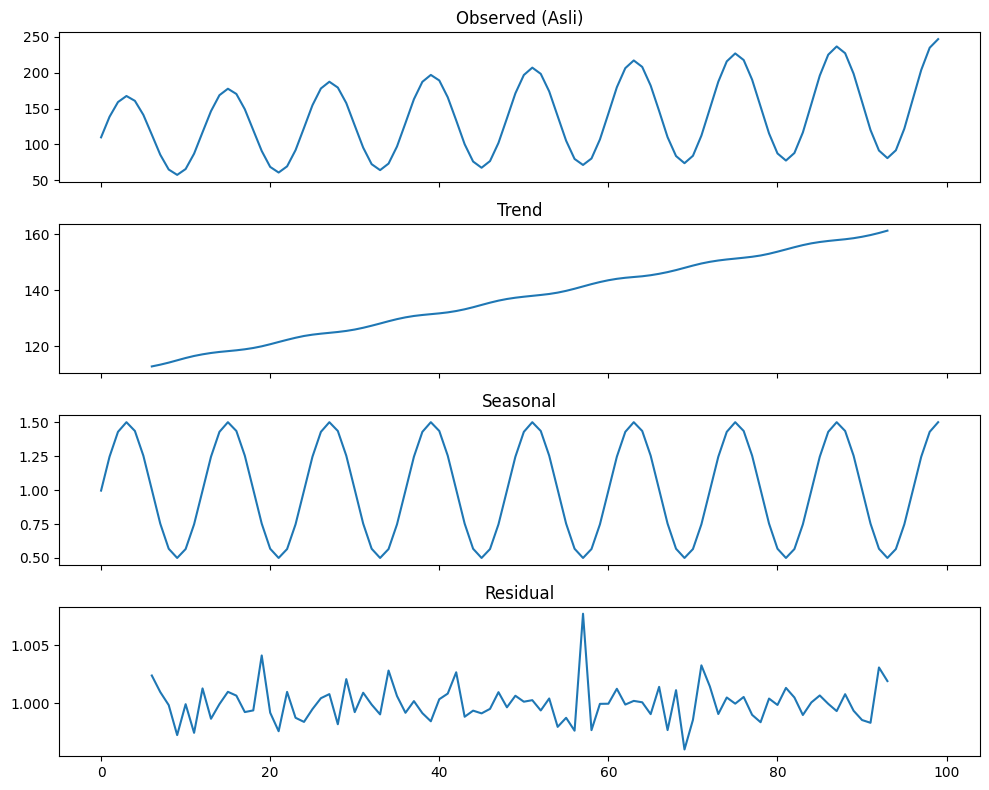

In [52]:
# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result_multi.observed.plot(ax=axes[0], title='Observed (Asli)')
result_multi.trend.plot(ax=axes[1], title='Trend')
result_multi.seasonal.plot(ax=axes[2], title='Seasonal')
result_multi.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana Anda menginterpretasikan plot hasil dekomposisi tersebut?

1. Observed (Data Asli)

Plot Observed menunjukkan data deret waktu asli yang merupakan gabungan dari tren meningkat dan pola musiman yang berulang.

Terlihat bahwa nilai deret secara umum meningkat dari sekitar 100–110 pada awal periode menjadi sekitar 240–250 pada akhir periode. Pada saat yang sama, terdapat pola naik-turun yang berulang secara teratur.

Jarak antar puncak dan lembah menunjukkan pola musiman sekitar 12 periode. Karena modelnya multiplikatif, besar fluktuasi musiman ikut meningkat seiring meningkatnya level/tren data.

2. Trend (Tren)

Komponen Trend menunjukkan kecenderungan jangka panjang setelah pengaruh musiman dan residual dipisahkan.

Pada plot terlihat tren meningkat secara stabil dan hampir linear, dari sekitar 112 pada awal periode hingga sekitar 161 pada akhir periode.

Hal ini menunjukkan adanya tren linear positif, yaitu nilai deret cenderung meningkat seiring bertambahnya waktu.

Jadi bagian sebelumnya yang mengatakan tren meningkat dari 100 hingga di atas 1000 harus diganti, karena berdasarkan plot ini skalanya hanya sekitar 112–161.

3. Seasonal (Musiman)

Komponen Seasonal menunjukkan pola musiman yang berulang secara teratur setiap sekitar 12 periode.

Karena menggunakan dekomposisi multiplikatif, faktor musiman berfluktuasi di sekitar:

$$ 1 $$

dengan kisaran sekitar:

$$ 0.5\leq Seasonal\leq1.5 $$

Interpretasinya:

Seasonal \(=1.5\) → nilai aktual sekitar 50% lebih tinggi daripada nilai tren.
Seasonal \(=1\) → nilai aktual berada sekitar 100% dari nilai tren.
Seasonal \(=0.5\) → nilai aktual sekitar 50% lebih rendah daripada nilai tren.

Dengan demikian, komponen seasonal menunjukkan bahwa efek musiman bersifat proporsional terhadap level tren, bukan berupa penambahan atau pengurangan dengan jumlah satuan yang tetap.

4. Residual

Komponen Residual menunjukkan variasi yang tersisa setelah pengaruh tren dan musiman dipisahkan.

Pada dekomposisi multiplikatif:

$$ Residual= \frac{Observed}{Trend\times Seasonal} $$

Nilai residual terlihat sangat dekat dengan 1, dengan sebagian besar pengamatan berada di sekitar 1.00.

Artinya, setelah komponen tren dan musiman diperhitungkan, hanya terdapat variasi acak yang relatif kecil yang belum dijelaskan oleh model dekomposisi.

Terdapat beberapa penyimpangan kecil dari angka 1, tetapi tidak menunjukkan pola yang besar atau sistematis.

In [55]:
# Parameter
np.random.seed(1011)
n = 100  # Jumlah titik data
x = np.arange(n)

# Hanya noise acak tanpa trend atau musiman
noise = np.random.normal(loc=10, scale=2, size=n)  # Nilai acak sekitar 10

# Buat DataFrame untuk regresi
df = pd.DataFrame({'Time': x, 'Series': noise})
df['Time'] = pd.to_datetime(df['Time'], unit='D')  # Konversi ke format waktu
df.set_index('Time', inplace=True)

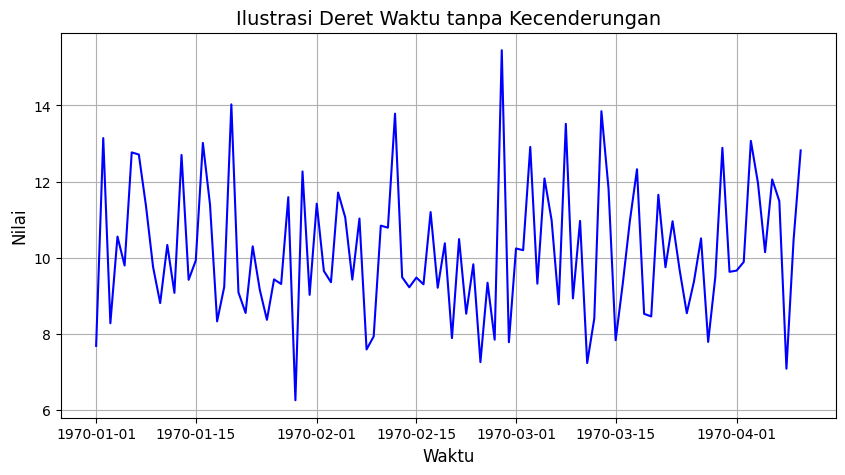

In [56]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Series'], color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu tanpa Kecenderungan', fontsize=14)
plt.grid()
plt.show()

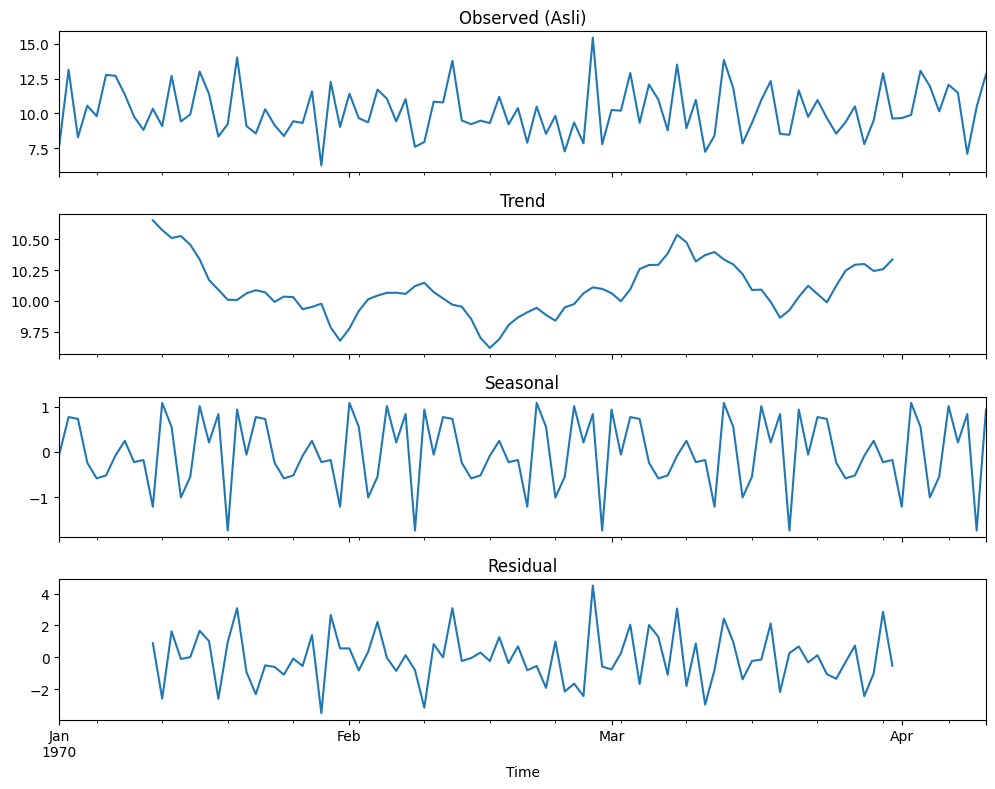

In [57]:
# Lakukan dekomposisi dengan model aditif
result = seasonal_decompose(df['Series'], model='additive', period=20)

# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana interpretasi dari plot tersebut?

1. Observed (Data Asli)

Pada plot Observed, nilai deret berfluktuasi cukup tajam, kira-kira pada rentang 7–15. Data naik dan turun secara tidak teratur sepanjang periode pengamatan.

Tidak terlihat adanya tren naik atau turun yang konsisten pada data asli. Fluktuasi yang muncul lebih dominan dan tidak membentuk pola musiman yang jelas.

2. Trend (Tren)

Komponen Trend menunjukkan perubahan jangka panjang dari data.

Terlihat bahwa tren:

awalnya berada di sekitar 10,5,
kemudian mengalami penurunan hingga sekitar 9,7,
setelah itu kembali meningkat,
mencapai sekitar 10,5,
lalu sedikit menurun dan kembali meningkat hingga sekitar 10,3.

Jadi, tren tidak menunjukkan kecenderungan naik atau turun secara konsisten, melainkan bergerak naik-turun secara perlahan di sekitar nilai 10.

3. Seasonal (Musiman)

Komponen Seasonal menunjukkan pola fluktuasi yang berulang dari waktu ke waktu.

Pada plot terlihat nilai seasonal bergerak kira-kira antara:

$$ -1.7 \leq Seasonal \leq 1.1 $$

Namun, pola naik-turunnya terlihat cukup tidak teratur dan tidak menunjukkan pola berulang yang kuat atau konsisten.

Karena komponen seasonal berada di sekitar 0, hal ini menunjukkan bahwa dekomposisi yang digunakan bersifat aditif, sehingga:

$$ Observed = Trend + Seasonal + Residual $$

Dengan kata lain, efek musiman ditambahkan dalam bentuk satuan absolut terhadap tren.

4. Residual

Komponen Residual menunjukkan bagian data yang tidak dapat dijelaskan oleh tren dan pola musiman.

Residual berfluktuasi di sekitar:

$$ 0 $$

dengan kisaran kira-kira −3 hingga 4.

Fluktuasinya terlihat cukup acak dan tidak membentuk pola tertentu. Ini menunjukkan bahwa setelah tren dan komponen musiman dipisahkan, masih terdapat variasi acak yang cukup besar dalam data.

Kesimpulan

Secara keseluruhan, hasil dekomposisi menunjukkan bahwa tren bergerak naik-turun secara perlahan di sekitar nilai 10, sementara komponen seasonal dan residual menunjukkan fluktuasi yang cukup besar. Tidak terlihat pola musiman yang sangat kuat dan teratur pada grafik. Oleh karena itu, variasi pada data asli lebih banyak dipengaruhi oleh fluktuasi acak dibandingkan tren atau pola musiman yang kuat.